# SHM: Cumulative Fatigue Damage Regression

**Approach: rainflow-counted features + gradient boosting (XGBoost / LightGBM).**

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import rainflow
from scipy import stats as sstats

DATA_DIR = "../../PS3/02_Datasets/SHM"
TRAIN_DIR = os.path.join(DATA_DIR, "Train")
TEST_DIR = os.path.join(DATA_DIR, "Test")
TRAIN_LABELS_PATH = os.path.join(DATA_DIR, "Train_Labels.csv")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Feature engineering

Two feature families per file:

- **Raw-signal statistics** — cheap, global descriptors of the stress distribution (mean, spread, shape, extremes).
- **Rainflow-cycle statistics** — amplitude/mean-stress distribution of the extracted stress cycles, plus a small family of *pseudo cumulative-damage* features `sum(count_i * amplitude_i^b)` for a few candidate S-N exponents `b`. This mirrors Miner's rule (`D = sum(n_i / N_i)`, with `N_i ∝ amplitude_i^-m`) without needing to know the true material constants `(m, C)` — we let gradient boosting learn how to combine several candidate exponents instead of committing to one.

In [2]:
def load_signal(path: str) -> np.ndarray:
    """Each file is a single column of raw stress readings, no header."""
    return np.loadtxt(path, dtype=np.float64)


def weighted_std(values: np.ndarray, weights: np.ndarray) -> float:
    avg = np.average(values, weights=weights)
    var = np.average((values - avg) ** 2, weights=weights)
    return float(np.sqrt(var))


def raw_signal_features(signal: np.ndarray) -> dict:
    return {
        "raw_mean": float(signal.mean()),
        "raw_std": float(signal.std()),
        "raw_rms": float(np.sqrt(np.mean(signal ** 2))),
        "raw_min": float(signal.min()),
        "raw_max": float(signal.max()),
        "raw_peak_to_peak": float(signal.max() - signal.min()),
        "raw_skew": float(sstats.skew(signal)),
        "raw_kurtosis": float(sstats.kurtosis(signal)),
    }


# Candidate S-N slope exponents (m) spanning the range typically seen for metals/composites.
PSEUDO_DAMAGE_EXPONENTS = (3, 5, 8, 10)


def rainflow_features(signal: np.ndarray) -> dict:
    cycles = list(rainflow.extract_cycles(signal))
    ranges = np.array([c[0] for c in cycles])
    means = np.array([c[1] for c in cycles])
    counts = np.array([c[2] for c in cycles])
    amplitudes = ranges / 2.0

    feats = {
        "rf_n_cycles": float(len(cycles)),
        "rf_total_cycle_count": float(counts.sum()),
        "rf_amp_mean": float(np.average(amplitudes, weights=counts)),
        "rf_amp_std": weighted_std(amplitudes, counts),
        "rf_amp_max": float(amplitudes.max()),
        "rf_amp_p90": float(np.percentile(amplitudes, 90)),
        "rf_amp_p99": float(np.percentile(amplitudes, 99)),
        "rf_mean_stress_mean": float(np.average(means, weights=counts)),
        "rf_mean_stress_std": weighted_std(means, counts),
    }
    for b in PSEUDO_DAMAGE_EXPONENTS:
        feats[f"rf_pseudo_damage_b{b}"] = float(np.sum(counts * amplitudes ** b))
    return feats


def extract_features(path: str) -> dict:
    signal = load_signal(path)
    feats = {"filename": os.path.basename(path)}
    feats.update(raw_signal_features(signal))
    feats.update(rainflow_features(signal))
    return feats

## 2. Build the training feature table

In [3]:
train_paths = sorted(glob.glob(os.path.join(TRAIN_DIR, "*.csv")))
print(f"{len(train_paths)} training files")

train_features = pd.DataFrame([extract_features(p) for p in train_paths])
labels = pd.read_csv(TRAIN_LABELS_PATH)

train_df = train_features.merge(labels, on="filename", how="left").sort_values("filename").reset_index(drop=True)
assert train_df["damage"].isna().sum() == 0, "Some training files are missing a label"

feature_cols = [c for c in train_df.columns if c not in ("filename", "damage")]
X_train = train_df[feature_cols]
y_train = train_df["damage"].to_numpy()

train_df.head()

64 training files


,filename,raw_mean,raw_std,raw_rms,raw_min,raw_max,raw_peak_to_peak,raw_skew,raw_kurtosis,rf_n_cycles,...,rf_amp_max,rf_amp_p90,rf_amp_p99,rf_mean_stress_mean,rf_mean_stress_std,rf_pseudo_damage_b3,rf_pseudo_damage_b5,rf_pseudo_damage_b8,rf_pseudo_damage_b10,damage
0,train01.csv,5.935077,8.631420,10.475044,-19.343730,39.391250,58.734980,-0.304332,0.014210,179181.0,...,29.367490,1.001239,2.438514,5.856657,8.688481,4.081619e+05,7.639325e+07,9.701530e+11,6.705652e+14,0.103663
1,train02.csv,-7.732028,10.753981,13.245089,-37.650806,25.297182,62.947988,0.179383,0.743291,165828.0,...,31.473994,0.707926,2.172099,-7.708126,10.854660,2.969098e+05,1.081352e+08,2.225301e+12,1.848319e+15,0.149209
2,train03.csv,1.926783,9.019781,9.223283,-28.079456,29.944937,58.024393,-0.191601,0.661141,173111.0,...,29.012197,0.869494,2.336367,1.944355,8.976219,3.246603e+05,8.278259e+07,1.228967e+12,8.365612e+14,0.111298
3,train04.csv,-2.477905,6.969852,7.397219,-54.097850,38.489470,92.587320,0.112379,0.206409,171874.0,...,46.293660,0.980041,3.920165,-2.549313,6.851483,1.470779e+06,6.692469e+08,3.041046e+13,5.353570e+16,0.894736
4,train05.csv,3.074598,8.830383,9.350337,-19.364319,29.429405,48.793724,0.076483,0.260781,176341.0,...,24.396862,0.599504,1.356325,3.136488,8.768979,1.540294e+05,4.200151e+07,4.332634e+11,2.238877e+14,0.054740


## 3. Scoring metric

The subsystem is graded on `score = max(0, 1 - MAPE)` (Info Kit Section 4) — reproduced here so cross-validation reports the same number the organisers will.

In [4]:
def mape_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mape = np.mean(np.abs(y_true - y_pred) / np.abs(y_true))
    return max(0.0, 1.0 - mape)

## 4. Cross-validation (leave-one-out)

With only 64 labelled files, a single train/validation split would be noisy and a k-fold split still leaves each fold estimate based on very few validation points. **Leave-one-out (LOO)** uses every file as a validation point exactly once — 64 cheap model fits — giving the most stable estimate of held-out performance available at this sample size. This is the explicit assumption we're making about the evaluation split, per the top-level spec's guidance to state such decisions where the documentation leaves them open.

In [5]:
from sklearn.model_selection import LeaveOneOut
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

MODEL_FACTORIES = {
    "xgboost": lambda: XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
    ),
    "lightgbm": lambda: LGBMRegressor(
        n_estimators=200,
        max_depth=3,
        num_leaves=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=5,
        random_state=RANDOM_STATE,
        verbosity=-1,
    ),
}


def loo_cv_score(model_name: str) -> tuple[float, np.ndarray]:
    loo = LeaveOneOut()
    preds = np.zeros(len(y_train))
    for train_idx, test_idx in loo.split(X_train):
        model = MODEL_FACTORIES[model_name]()
        model.fit(X_train.iloc[train_idx], y_train[train_idx])
        preds[test_idx] = model.predict(X_train.iloc[test_idx])
    return mape_score(y_train, preds), preds


cv_results = {}
for name in MODEL_FACTORIES:
    score, preds = loo_cv_score(name)
    cv_results[name] = (score, preds)
    print(f"{name:10s} LOO score = {score:.4f}")

best_model_name = max(cv_results, key=lambda k: cv_results[k][0])
print(f"\nBest model: {best_model_name}")

xgboost    LOO score = 0.9276
lightgbm   LOO score = 0.9120

Best model: xgboost


## 5. Refit the best model on all training data + inspect feature importance

In [6]:
final_model = MODEL_FACTORIES[best_model_name]()
final_model.fit(X_train, y_train)

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances

rf_amp_max              0.268989
rf_pseudo_damage_b8     0.236378
rf_pseudo_damage_b5     0.217844
rf_pseudo_damage_b10    0.137993
rf_pseudo_damage_b3     0.066482
raw_peak_to_peak        0.040874
raw_min                 0.012874
rf_amp_p90              0.006355
rf_total_cycle_count    0.003807
raw_rms                 0.003002
raw_mean                0.002454
raw_std                 0.001087
raw_skew                0.000808
rf_n_cycles             0.000575
raw_max                 0.000160
rf_mean_stress_std      0.000097
rf_amp_p99              0.000095
rf_amp_std              0.000054
rf_amp_mean             0.000037
raw_kurtosis            0.000023
rf_mean_stress_mean     0.000013
dtype: float32

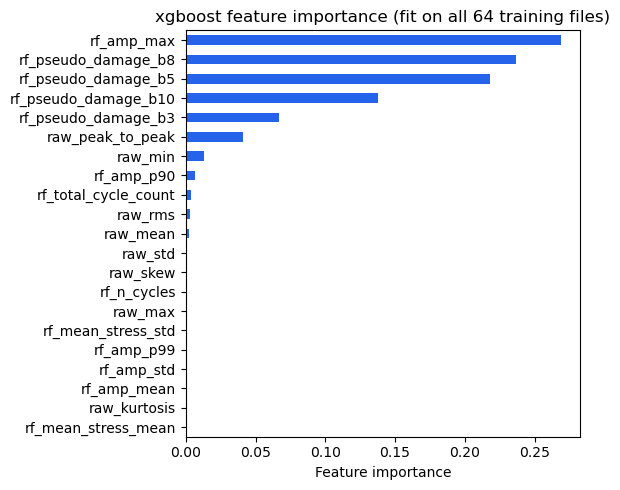

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
importances.sort_values().plot.barh(ax=ax, color="#2563eb")
ax.set_xlabel("Feature importance")
ax.set_title(f"{best_model_name} feature importance (fit on all 64 training files)")
fig.tight_layout()
plt.show()

## 6. Run inference on the held-out Test files and write the submission CSV

In [8]:
test_paths = sorted(glob.glob(os.path.join(TEST_DIR, "*.csv")))
print(f"{len(test_paths)} test files")

test_features = pd.DataFrame([extract_features(p) for p in test_paths])
X_test = test_features[feature_cols]

test_predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    "file_id": test_features["filename"],
    "prediction": test_predictions,
}).sort_values("file_id").reset_index(drop=True)

submission

16 test files


,file_id,prediction
0,test01.csv,0.032811
1,test02.csv,0.861178
2,test03.csv,0.517663
3,test04.csv,0.029026
4,test05.csv,0.034689
5,test06.csv,0.449399
6,test07.csv,0.159742
7,test08.csv,0.056069
8,test09.csv,0.066456
9,test10.csv,0.058121


In [9]:
output_path = "shm_predictions.csv"
submission.to_csv(output_path, index=False)
print(f"Wrote {len(submission)} predictions to {output_path}")

Wrote 16 predictions to shm_predictions.csv


## 7. Save the trained model for reuse in the app

In [10]:
import joblib

joblib.dump(
    {"model": final_model, "feature_cols": feature_cols, "model_name": best_model_name},
    "shm_model.joblib",
)
print("Saved shm_model.joblib")

Saved shm_model.joblib
